In [1]:
# Put import statements here
import sys
import subprocess
from pathlib import Path

# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.util.logger import Logger


In [2]:
# Run pytest setup tests to verify the environment/hardware is good to go
#subprocess.run(
#    [sys.executable, "-m", "pytest", "-q", "test/test_setup.py"],
#    check=False,
#)

In [3]:
# Quick example of how to use the custom logger class I made
# Delete this section later
# This is just to help with keeping logs pretty
# The logger can be used from any class, after it is imported

# you can do some minor configuration of the logging in src/config.py

Logger.info("Example of how to log at info level")
Logger.debug("Example of how to log at debug level")
Logger.warning("Example of how to log at warning level")
Logger.error("Example of how to log at error level")
Logger.critical("Example of how to log at critical level")



13:14:46 [INFO    ]: Example of how to log at info level
13:14:46 [DEBUG   ]: Example of how to log at debug level
13:14:46 [WARNING ]: Example of how to log at warning level
13:14:46 [ERROR   ]: Example of how to log at error level
13:14:46 [CRITICAL]: Example of how to log at critical level


In [4]:
# Determine the project root's location, that way file paths will be more consistent
PROJECT_ROOT= Path.cwd()
DATA_DIR= PROJECT_ROOT / "data"

Logger.info(f"Project root absolute path: {PROJECT_ROOT}")

13:14:46 [INFO    ]: Project root absolute path: /home/chris/capstone/PlantQA


In [5]:
# load the plantExpertVQA training dataset
plant_expert_vqa_data_path= DATA_DIR / "PlantExpertVQA" / "data"
train_data_path= plant_expert_vqa_data_path / "test.csv" 

plant_expert_vqa_train= text_pre.load_csv(train_data_path)

# Explore the basics of the training set
print("\n\n")
text_explore.explore_data(plant_expert_vqa_train, "Plant Expert VQA Training Dataset")

13:14:46 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152921 entries, 0 to 152920
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              152921 non-null  object
 1   image_id           152921 non-null  object
 2   image_path         152921 non-null  object
 3   crop               152921 non-null  object
 4   disease            152921 non-null  object
 5   category           152921 non-null  object
 6   severity           152921 non-null  object
 7   question_text      152013 non-null  object
 8   answer             152013 non-null  object
 9   answer_type        48823 non-null   object
 10  question_category  152013 non-null  object
 11  cognitive_level    152013 non-null  object
 12  dataset_source     152921 non-null  object
dtypes: object(13)
memory usage: 15.

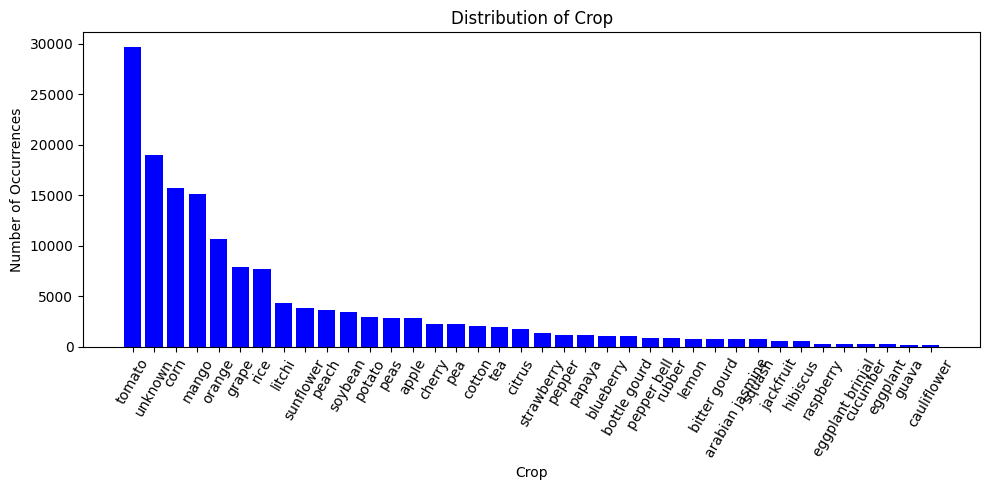

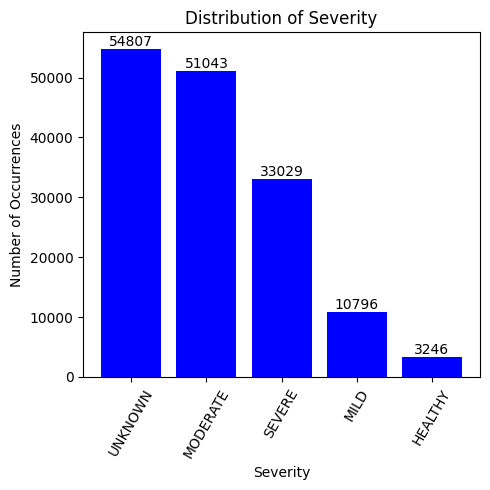

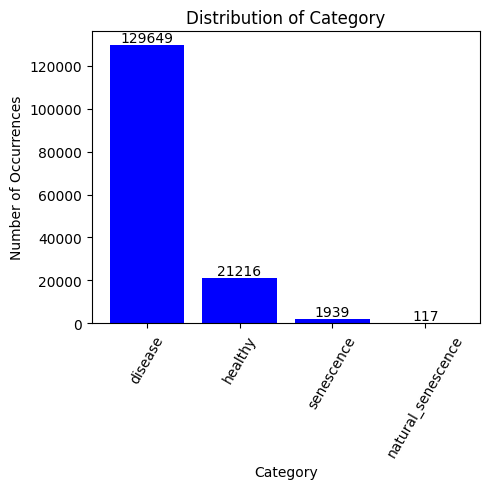

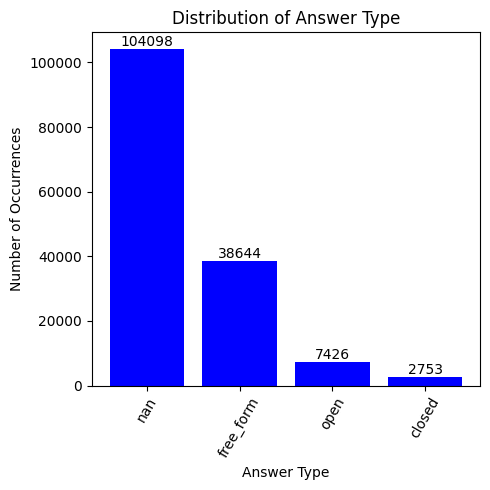

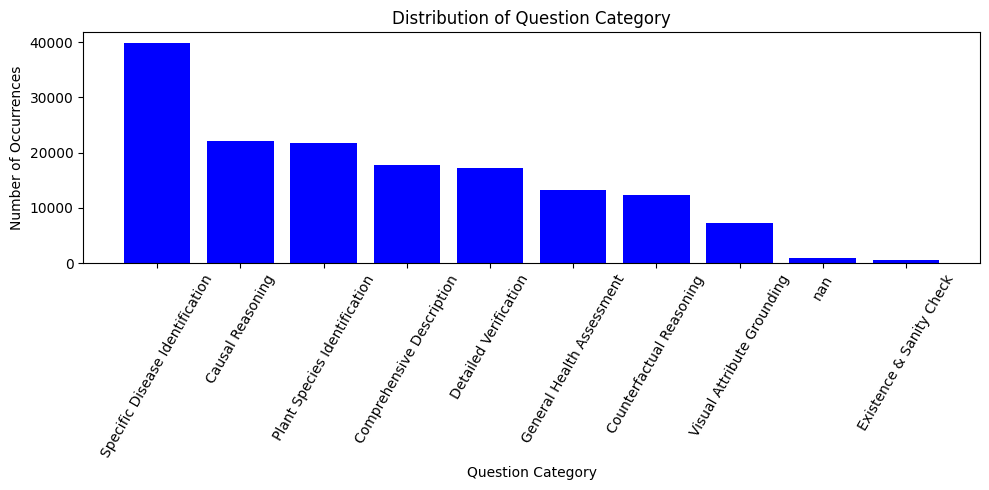

In [9]:
# make distributions of some columns, so we know how common each type is
text_explore.make_column_distribution_graph(plant_expert_vqa_train, "crop", size=(10,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_train, "severity", show_counts=True, size=(5,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_train, "category", show_counts=True, size=(5,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_train, "answer_type", show_counts=True, size=(5,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_train, "question_category", show_counts=False, size=(10,5))
